In [1]:
# Import necessary libraries
%load_ext autoreload
%autoreload 2

import sys
import os
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars import population

# # Let's import some useful functions for plotting simulation results over time.
from mars import visualization

In [2]:
dtype = torch.float64

### 1. Continious wave classical EPR spectrum

In [193]:
g_tensor = spin_model.Interaction([2.06, 2.004, 2.20])
#A_tensor = spin_model.Interaction([70e6, 70e6, 70e6])

spin_system = spin_model.SpinSystem(electrons=[0.5], g_tensors=[g_tensor])
sample = spin_model.MultiOrientedSample(base_spin_system=spin_system, lorentz=0.0025, ham_strain=3e7, mesh=(50, 50))

fields = torch.linspace(0.30, 0.375, 1000)
freq = 9.8e9

creator = spectra_manager.StationarySpectra(freq=freq, sample=sample, temperature=100.0)
spectrum = creator(sample=sample, fields=fields)

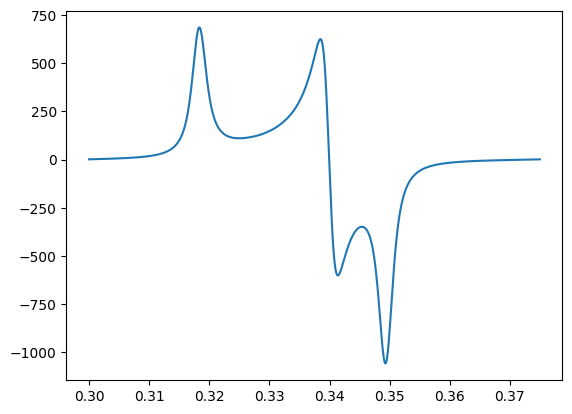

In [194]:
plt.plot(fields, spectrum)
plt.savefig("example_1.eps")

### 2. Spin-Polarized EPR

In [199]:
g_tensor = spin_model.Interaction([2.004, 2.002, 2.009])
zfs = spin_model.DEInteraction([400e6, 40e6])

spin_system = spin_model.SpinSystem(electrons=[1.0], g_tensors=[g_tensor], electron_electron=[(0, 0, zfs)])
sample = spin_model.MultiOrientedSample(base_spin_system=spin_system, lorentz=0.001, ham_strain=1e6, mesh=(50, 50))

fields = torch.linspace(0.32, 0.38, 1000)
freq = 9.8e9

context = population.Context(basis="xyz", sample=sample, init_populations=[0.25, 0.5, 0.2])
creator = spectra_manager.StationarySpectra(freq=freq, sample=sample, temperature=100.0, harmonic=0, context=context)
spectrum = creator(sample=sample, fields=fields)

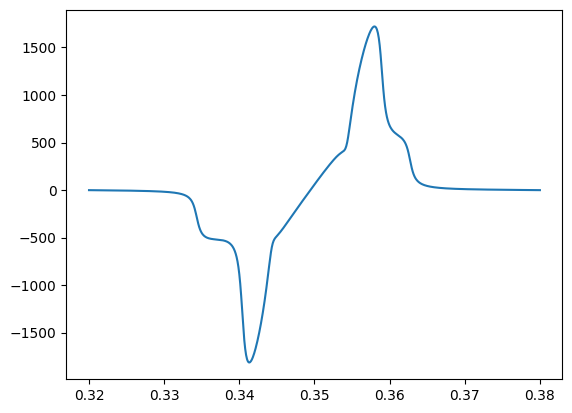

In [201]:
plt.plot(fields, spectrum)
plt.savefig("example_2.eps")

### 3. Freq_dependant

In [359]:
mesh = mesher.CrystalMesh(euler_angles=torch.tensor([0, 0, 0.0]))

g_tensor = spin_model.Interaction([2.004, 2.004, 2.004])
zfs = spin_model.DEInteraction(constants.unit_converter(25, "cm-1_to_Hz"))

spin_system = spin_model.SpinSystem(electrons=[1.5], g_tensors=[g_tensor], electron_electron=[(0, 0, zfs)])
sample = spin_model.MultiOrientedSample(base_spin_system=spin_system, lorentz=0.001, ham_strain=5e10, mesh=mesh)

In [379]:
freq = torch.linspace(constants.unit_converter(30, "cm-1_to_Hz"), constants.unit_converter(70, "cm-1_to_Hz"), 1000)


spectra = []
fields = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0]
for field in fields:
    creator = spectra_manager.StationaryFreqSpectra(field=field, sample=sample, temperature=15.0, harmonic=0)
    spectrum = creator(sample=sample, freq=freq)

    spectra.append(spectrum)

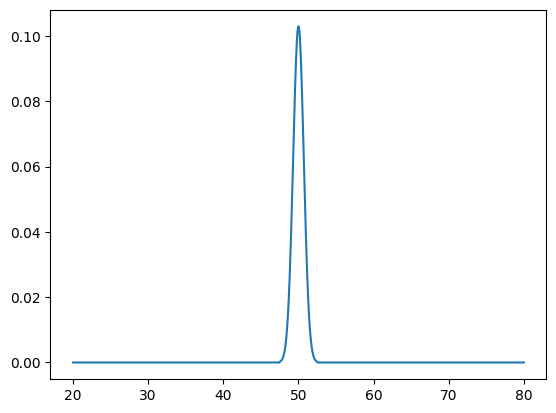

In [361]:
plt.plot(constants.unit_converter(freq, "Hz_to_cm-1"), spectrum)

In [380]:
def plot_stacked_spectra(freq_hz, spectra, fields, ax=None, **plot_kwargs):
    """
    Plot spectra vs frequency for multiple fields, stacked vertically without y-axis.
    
    Spectra appear from bottom (lowest field) to top (highest field) in one plot.
    Field labels are placed at the right end of each trace for quick reference.
    
    Conceptually: each spectrum is shifted up by a fixed offset so they don't overlap,
    while sharing the same frequency axis.
    
    Parameters
    ----------
    freq_hz : torch.Tensor or array-like
        Frequency values in Hz (output of torch.linspace with unit_converter).
    spectra : list of torch.Tensor or array-like
        Spectral intensity arrays, one per field value.
    fields : list of float
        Magnetic field values in Tesla, matching the order of spectra.
    ax : matplotlib.axes.Axes, optional
        Target axes for plotting. Creates new figure/axes if None.
    **plot_kwargs : dict, optional
        Extra arguments passed to ax.plot() (e.g., linewidth, color).
    
    Note
    ----
    Frequency axis is automatically converted from Hz to cm⁻¹ for readability,
    matching your original 20–80 cm⁻¹ range.
    """
    # Convert Hz → cm⁻¹ (c = 2.99792458e10 cm/s)
    c_cm_s = 2.99792458e10
    freq_cm = freq_hz.cpu().numpy() / c_cm_s if hasattr(freq_hz, "cpu") else np.asarray(freq_hz) / c_cm_s
    
    # Prepare axes
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    # Convert spectra to numpy for plotting
    specs_np = [s.cpu().numpy() if hasattr(s, "cpu") else np.asarray(s) for s in spectra]
    
    # Compute vertical offset: 1.2× the largest peak-to-peak range
    max_amp = max(np.max(s) - np.min(s) for s in specs_np)
    offset = 1.2 * max_amp
    
    # Plot each spectrum with offset and field label
    for idx, (field, spec) in enumerate(zip(fields, specs_np)):
        y_shifted = spec + idx * offset
        line = ax.plot(freq_cm, y_shifted, **plot_kwargs)[0]
        # Place field label at right end of trace
        ax.text(freq_cm[-1], y_shifted[-1], f"  {field} T", 
                va='center', fontsize=9, color=line.get_color())
    
    # Clean up: remove y-axis, keep only x-axis label
    ax.set_xlabel("Frequency (cm⁻¹)")
    ax.set_yticks([])
    for spine in ['left', 'right', 'top']:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.25)
    
    plt.tight_layout()
    # No return — plotting done in-place per your preference

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


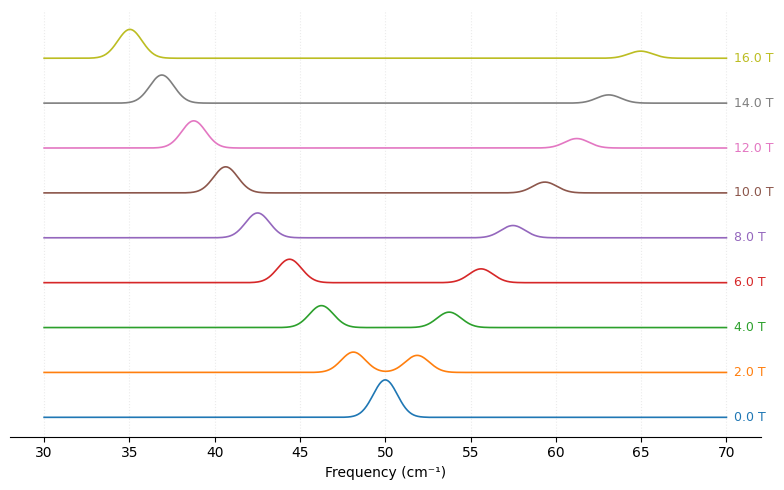

In [382]:
plot_stacked_spectra(freq, spectra, fields, linewidth=1.2)
plt.savefig("example_3.eps")
plt.show()

### 4. Time-Resolved EPR populations

In [391]:
g_tensor = spin_model.Interaction([2.004, 2.002, 2.009])
zfs = spin_model.DEInteraction([400e6, 40e6])

spin_system = spin_model.SpinSystem(electrons=[1.0], g_tensors=[g_tensor], electron_electron=[(0, 0, zfs)])
sample = spin_model.MultiOrientedSample(base_spin_system=spin_system, lorentz=0.001, ham_strain=1e6, mesh=(20, 20))

fields = torch.linspace(0.33, 0.365, 1000)
time = torch.linspace(0.0, 1e-1, 600)
freq = 9.8e9

context = population.Context(basis="xyz", sample=sample, init_populations=[0.25, 0.5, 0.2], out_probs=[100, 20, 100])

creator = spectra_manager.CoupledTimeSpectra(freq=freq, sample=sample, temperature=100.0, harmonic=0, context=context)
spectrum = creator(sample=sample, fields=fields, time=time)

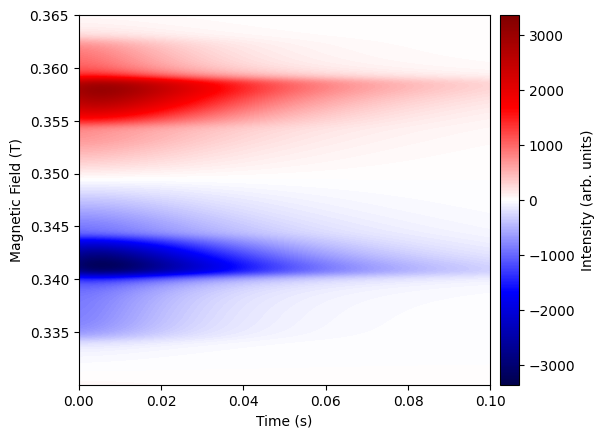

In [392]:
visualization.time_resolved.plot_2d_timeresolved(fields=fields, time=time, result=spectrum)

### 5. Time-Resolved EPR Density

In [16]:
g_tensor = spin_model.Interaction([2.004, 2.004, 2.004], dtype=dtype)

zfs = spin_model.DEInteraction([400e6, 0e6], dtype=dtype)

spin_system = spin_model.SpinSystem(electrons=[1.0], g_tensors=[g_tensor], electron_electron=[(0, 0, zfs)], dtype=dtype)
sample = spin_model.MultiOrientedSample(base_spin_system=spin_system, lorentz=0.001, ham_strain=1e6, dtype=dtype)

fields = torch.linspace(0.335, 0.365, 1000, dtype=dtype)
time = torch.linspace(0.0, 2e-4, 1000, dtype=dtype)
freq = 9.8e9

context = population.Context(basis="xyz", sample=sample, init_populations=[0.3, 0.5, 0.2], out_probs=[10000, 2000, 10000], dtype=dtype)
context_eigen = population.Context(dephasing=[1e5, 1e5, 1e5], dtype=dtype)
context = context + context_eigen

creator = spectra_manager.DensityTimeSpectra(freq=freq, sample=sample, temperature=100.0, harmonic=0, context=context, populator="rwa", dtype=dtype)
spectrum = creator(sample=sample, fields=fields, time=time)

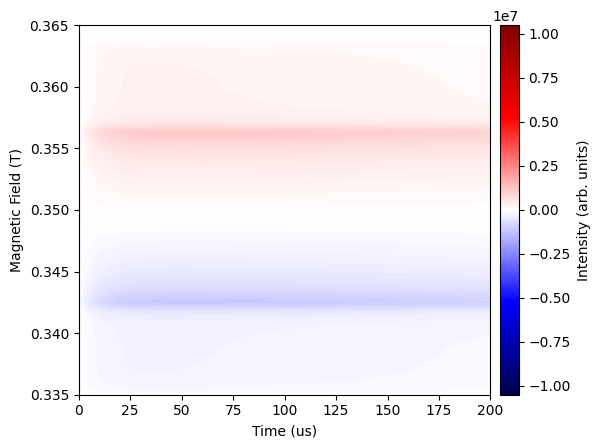

In [17]:
visualization.time_resolved.plot_2d_timeresolved(fields=fields, time=time, result=spectrum, vmax_clip=1e7, time_unit="us")
plt.savefig("example_4.eps")

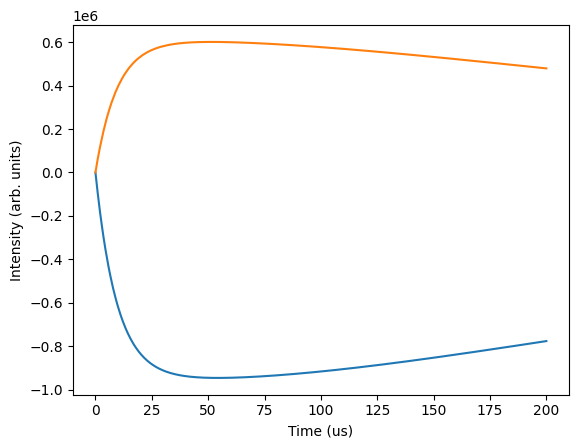

In [294]:
visualization.time_resolved.plot_kinetic(field_value=0.3425, fields=fields, time=time, result=spectrum, time_unit="us")
visualization.time_resolved.plot_kinetic(field_value=0.355, fields=fields, time=time, result=spectrum, time_unit="us")

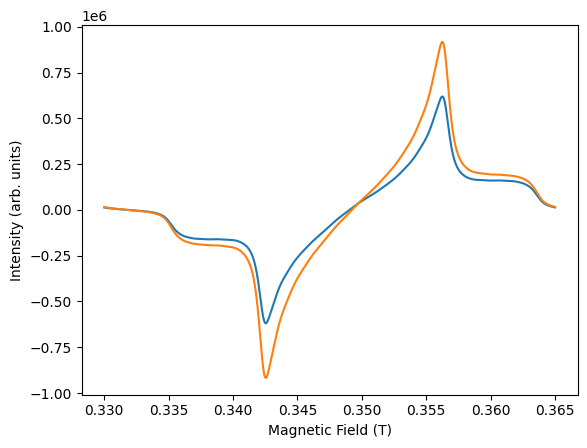

In [304]:
visualization.time_resolved.plot_field_dependence(time_value=10e-6, fields=fields, time=time, result=spectrum)
visualization.time_resolved.plot_field_dependence(time_value=100e-6, fields=fields, time=time, result=spectrum)